In [1]:
# Standard library
import json
from copy import copy
from math import ceil, isfinite
from pathlib import Path
from time import monotonic
from typing import Any

# Math
import numpy as np
from numpy import array, deg2rad, eye, mean, ndarray, pi, set_printoptions, stack, rad2deg, deg2rad
from numpy.random import seed, standard_normal
from scipy.stats import norm, uniform

# Data Handling
import utm
import pandas as pd
from filterpy.monte_carlo import systematic_resample, stratified_resample

# Other Third Party
from rich.progress import track

# Plotting
import matplotlib
from keplergl import KeplerGl
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.transforms import Affine2D
from seaborn import move_legend
from svgpath2mpl import parse_path
from svgpathtools import svg2paths
import seaborn as sns

# ProMis
from promis import ProMis, DeltaStaRMap
from promis.geo import (
    CartesianCollection,
    DeltaGrid,
    CartesianDeltaCollection,
    CartesianLocation,
    CartesianMap,
    CartesianRasterBand,
    PolarCollection,
    PolarLocation,
)
from promis.loaders import OsmLoader
from promis.logic.spatial import Depth


In [2]:
# This will auto-relead changed ProMis imports
%reload_ext autoreload
%autoreload 2

# The inD Dataset
https://levelxdata.com/ind-dataset/

https://levelxdata.com/wp-content/uploads/2024/03/inD-Format_1_1.pdf


In [3]:
# data_path = Path(".") / "data" / "athens_cars"
# car_data = pd.read_csv(data_path / "20181101_d9_0830_0900.csv", sep='; ', header=0)
data_path = Path(".") / "data" / "inD-dataset-v1.1" / "data"

inD_index = "08"
metadata = pd.read_csv(data_path / f"{inD_index}_recordingMeta.csv", sep=',')
car_data = pd.read_csv(data_path / f"{inD_index}_tracks.csv", sep=',')
car_metadata = pd.read_csv(data_path / f"{inD_index}_tracksMeta.csv", sep=',')
assert metadata["recordingId"].unique() == car_data["recordingId"].unique() == car_metadata["recordingId"].unique()
metadata

,recordingId,locationId,frameRate,speedLimit,weekday,startTime,duration,numTracks,numVehicles,numVRUs,latLocation,lonLocation,xUtmOrigin,yUtmOrigin,orthoPxToMeter
0,8,1,25.0,13.88889,tuesday,NaN,1065.6,415,284,131,50.78206,6.07117,293487.1224,5.629712e+06,0.008146


In [4]:
# naive center of the scene, but not our origin of coordinates
# we use this as a bootstrap
origin = PolarLocation(
    latitude=metadata["latLocation"][0], longitude=metadata["lonLocation"][0]
)

# the dataset uses a local coordinate frame based on the UTM projection.
# the local frame resembles a CartesianCollection, we just need to transform its origin point
origin_coords = utm.to_latlon(
    easting=metadata["xUtmOrigin"][0],
    northing=metadata["yUtmOrigin"][0],
    zone_number=utm.latlon_to_zone_number(origin.latitude, origin.longitude),
    zone_letter=utm.latitude_to_zone_letter(origin.latitude),
)
origin = PolarLocation(longitude=origin_coords[1], latitude=origin_coords[0])

# we now want to translate the origin to the approximate center of the scene
# that way, we avoid to compute lots of uninteresting points
bounds = [[car_data[row].max(), car_data[row].min()] for row in ["xCenter", "yCenter"]]
offsets = [mean(bound_pair) for bound_pair in bounds]
diameter = 60 # max([bound_pair[0] - bound_pair[1] for bound_pair in bounds]) * 1.2

origin = CartesianLocation(*offsets).to_polar(origin)
dimensions = width, height = diameter, diameter

collection = CartesianDeltaCollection(origin=origin, number_of_values=0)
car_data["xCenter"] = car_data["xCenter"] - offsets[0]
car_data["yCenter"] = car_data["yCenter"] - offsets[1]
car_data["speed"] = np.sqrt(np.pow(car_data["xVelocity"], 2) + np.pow(car_data["yVelocity"], 2)) * 3.6
car_data = car_data.join(car_metadata[["trackId", "class"]], on="trackId", how="left", rsuffix="r", validate="m:1")

del car_data["trackIdr"]

collection.append_with_default(car_data[["xCenter", "yCenter", "heading", "speed"]].values, value=())
car_data


,recordingId,trackId,frame,trackLifetime,xCenter,yCenter,heading,width,length,xVelocity,yVelocity,xAcceleration,yAcceleration,lonVelocity,latVelocity,lonAcceleration,latAcceleration,speed,class
0,8,0,0,0,-4.245085,-8.423345,41.37113,1.86488,4.76778,0.02392,-0.02959,-0.05838,0.04144,-0.00161,0.03802,-0.01642,-0.06968,0.136977,car
1,8,0,1,1,-4.244175,-8.424735,41.37123,1.86488,4.76778,0.02162,-0.02787,-0.05988,0.04248,-0.00219,0.03520,-0.01686,-0.07145,0.126982,car
2,8,0,2,2,-4.243305,-8.426335,41.37068,1.86488,4.76778,0.01925,-0.02590,-0.06140,0.04334,-0.00267,0.03216,-0.01743,-0.07311,0.116173,car
3,8,0,3,3,-4.241835,-8.427655,41.36932,1.86488,4.76778,0.01651,-0.02376,-0.06280,0.04387,-0.00331,0.02875,-0.01813,-0.07443,0.104159,car
4,8,0,4,4,-4.240685,-8.428745,41.36851,1.86488,4.76778,0.01350,-0.02154,-0.06380,0.04397,-0.00410,0.02508,-0.01882,-0.07517,0.091515,car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260343,8,414,26635,140,13.471665,-19.081545,312.17367,1.70731,4.40397,6.24817,-6.89364,-0.24761,0.22859,9.30387,-0.00235,-0.33565,0.03004,33.493913,car
260344,8,414,26636,141,13.720725,-19.357665,312.15562,1.70731,4.40397,6.23829,-6.88514,-0.24743,0.22773,9.29093,-0.00366,-0.33488,0.03059,33.447355,car
260345,8,414,26637,142,13.969875,-19.633525,312.15123,1.70731,4.40397,6.22850,-6.87642,-0.24731,0.22738,9.27789,-0.00297,-0.33455,0.03076,33.400428,car
260346,8,414,26638,143,14.218905,-19.908985,312.15111,1.70731,4.40397,6.21867,-6.86748,-0.24728,0.22731,9.26467,-0.00170,-0.33447,0.03079,33.352817,car


In [5]:
setting = f"inD-crossing-{inD_index}"
output_folder = Path(".") / "ground-cofi-exports" / setting
output_folder.mkdir(exist_ok=True, parents=True)

In [6]:
feature_description = {
    # "primary": "['highway' = 'primary']",
    "secondary": "['highway' = 'secondary']",
    "tertiary": "['highway' = 'tertiary']",
    # "service": "['highway' = 'service']",
    # "residential": "['highway' = 'residential']",
    # "crossing": "['footway' = 'crossing']",
    # "living_street": "[highway=living_street]",
    "unclassified": "['highway' = 'unclassified']",
    "signal": "['highway' = 'traffic_signals']",
}

covariance = {
    "secondary": 3 * np.eye(2),
    "tertiary": 2 * np.eye(2),
    "crossing": 1.5 * np.eye(2),
    "unclassified": 2 * np.eye(2),
}

general_logic = """
    unclassified_side_correct(X) :-
        follows(X, unclassified),
        on_right_side(X, unclassified);
        \+follows(X, unclassified),
        \+on_right_side(X, unclassified).

    unclassified_correct(X) :-
        over(X, unclassified),
        unclassified_side_correct(X),
        state_speed(X, S),
        maxspeed(X, unclassified, MS),
        MS >= S.

    tertiary_side_correct(X) :-
        follows(X, tertiary),
        on_right_side(X, tertiary);
        \+follows(X, tertiary),
        \+on_right_side(X, tertiary).

    tertiary_correct(X) :-
        over(X, tertiary),
        tertiary_side_correct(X),
        state_speed(X, S),
        maxspeed(X, tertiary, MS),
        MS >= S.
        

    % Definition of a valid mission
    landscape(X) :-
        tertiary_correct(X);
        unclassified_correct(X).
"""

In [7]:
reload_uam = False
uam: CartesianMap
if reload_uam or not Path(output_folder / "uam.pkl").exists():
    uam = OsmLoader(
        origin=origin,
        dimensions=dimensions,
        feature_description=feature_description,
        polygonize_routes=True,
        timeout=15,
    ).to_cartesian_map()
else: 
    uam = CartesianMap.load(output_folder / "uam.pkl")


In [8]:
uam.apply_covariance(covariance)
uam.save(output_folder / "uam.pkl")

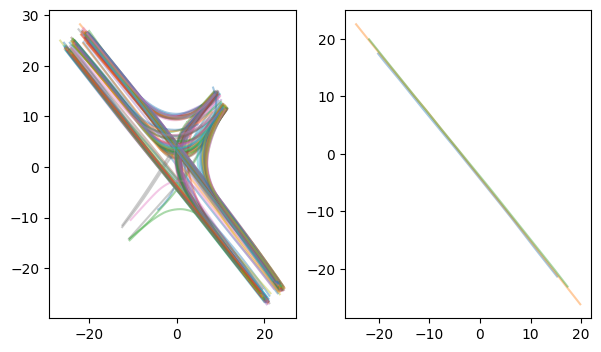

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(7,4))
cars = car_data[car_data["class"] == "car"]
trucks = car_data[car_data["class"] == "truck_bus"]


for i, df in enumerate([cars, trucks]):
    for trackId in df["trackId"].unique():
        track = df[df["trackId"] == trackId]
        ax[i].plot(track["xCenter"], track["yCenter"], alpha = 0.4)


In [10]:
reload_star = False
dsm: DeltaStaRMap
if reload_star:
    support = DeltaGrid(origin, (40, 40), width, height, speed_res=3, speed_bounds=(35, 55))
    dsm = DeltaStaRMap(uam)
    dsm.initialize(support, 15, general_logic)
    dsm.save(output_folder / "star.pkl")
else:
    dsm = DeltaStaRMap.load(output_folder / "star.pkl")

In [11]:
print(dsm.get("follows", "tertiary").parameters.data["v0"].unique())
print([i / 15 for i in range(16)])

[0.         0.93333333 1.         0.86666667 0.8        0.73333333
 0.66666667 0.46666667 0.06666667 0.13333333 0.26666667 0.33333333
 0.6        0.53333333 0.2        0.4       ]
[0.0, 0.06666666666666667, 0.13333333333333333, 0.2, 0.26666666666666666, 0.3333333333333333, 0.4, 0.4666666666666667, 0.5333333333333333, 0.6, 0.6666666666666666, 0.7333333333333333, 0.8, 0.8666666666666667, 0.9333333333333333, 1.0]


Text(0.5, 0.98, 'different StaRs on tertiary road type')

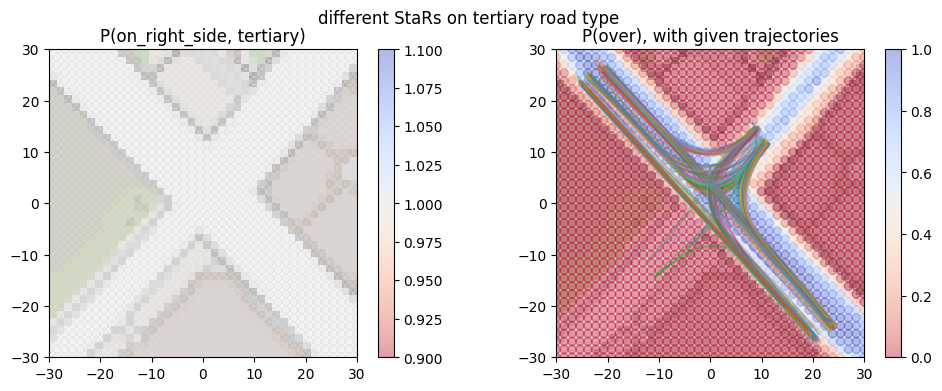

In [12]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
params = dsm.get("follows", "unclassified").parameters
params.number_of_values = 2
plot = params.scatter(value_index=0, bearing=235, speed=35, alpha=0.4, cmap="coolwarm_r", ax=ax[0])
plt.colorbar(plot)
params = dsm.get("over", "tertiary").parameters
plot = params.scatter(value_index=0, bearing=0, speed=30, alpha=0.4, cmap="coolwarm_r", ax=ax[1])
plt.colorbar(plot)
df = car_data[car_data["class"] == "car"]
for trackId in df["trackId"].unique():
    track = df[df["trackId"] == trackId]
    ax[1].plot(track["xCenter"], track["yCenter"], alpha = 0.4)

ax[0].set_title("P(on_right_side, tertiary)")
ax[1].set_title("P(over), with given trajectories")
fig.suptitle("different StaRs on tertiary road type")

add an any location type, 
left_side, right_side? das könnte es eleganter machen

{'maxspeed': '50', 'lanes': '1', 'oneway': 'no', 'line': PolarPolyLine(locations=[PolarLocation(latitude=50.78274189999999, longitude=6.07203100000001, identifier=3363379706503761016), PolarLocation(latitude=50.7825344, longitude=6.0717922999999985, identifier=551879331362692149), PolarLocation(latitude=50.782421699999986, longitude=6.0716514000000075, identifier=1728939079230533241), PolarLocation(latitude=50.7821807, longitude=6.071358099999998, identifier=256274784850727219), PolarLocation(latitude=50.7821184, longitude=6.071271899999999, identifier=4012699396960622646), PolarLocation(latitude=50.782056100000005, longitude=6.071185600000007, identifier=2832960903690986530)], location_type=tertiary, identifier=1363461377066636442)}
{'lanes': '2', 'maxspeed': '50', 'oneway': 'no', 'line': PolarPolyLine(locations=[PolarLocation(latitude=50.78649819999998, longitude=6.063929099999996, identifier=3377229292081119581), PolarLocation(latitude=50.786281, longitude=6.064207699999997, identif

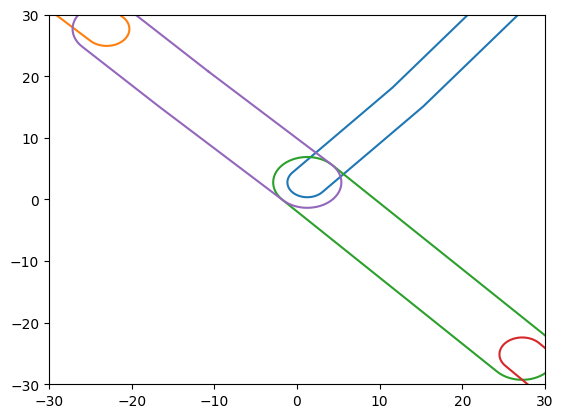

In [13]:
ax = plt.subplot(xlim=(-30, 30), ylim=(-30, 30))
from promis.geo import CartesianPolygon
for f in uam.features:
    if f.location_type == "tertiary" and isinstance(f, CartesianPolygon): 
        ax.plot(*f.geometry.exterior.xy)
        print(f.tags)

In [14]:
# # command line script
# from promis import ProMis, DeltaStaRMap
# from promis.geo import DeltaGrid
# from pathlib import Path

# general_logic = """
#     on_road(X) :-
#         on_tertiary(X);
#         on_unclassified(X);
#         over(X, service).

#     on_unclassified(X) :-
#         over(X, unclassified),
#         state_speed(X, S),
#         maxspeed(X, unclassified, MS),
#         MS >= S.
    
#     obeys_direction(X) :-
#         follows(X, tertiary),
#         on_right_side(X, tertiary);
#         \+follows(X, tertiary),
#         \+on_right_side(X, tertiary);
#         follows(X, unclassified),
#         on_right_side(X, unclassified);
#         \+follows(X, unclassified),
#         \+on_right_side(X, unclassified).

#     on_tertiary(X) :-
#         over(X, tertiary),
#         state_speed(X, S),
#         maxspeed(X, tertiary, MS),
#         MS >= S.

#     % Definition of a valid mission
#     landscape(X) :-
#         on_road(X),
#         obeys_directions(X),
#         respects_walkers(X).
# """
# origin = PolarLocation(latitude=50.782031183109694, longitude=6.071167919731977)
# width, height = 60, 60

# output_folder = Path('ground-cofi-exports/inD-crossing-08')

# support = DeltaGrid(origin, (40, 40), width, height, speed_res=3, speed_bounds=(35, 55), bearing_res=13)
# dsm = DeltaStaRMap.load(output_folder / "dsm.pkl")
# promis = ProMis(dsm)
# promis.solve(support, general_logic, print_first=True, show_progress=True)
# support.save(output_folder / "landscape.pkl")

In [15]:
# promis = ProMis(dsm)
# promis.solve(support, general_logic, print_first=True, show_progress=True)
support = DeltaGrid.load(output_folder / "landscape.pkl")
output_folder

PosixPath('ground-cofi-exports/inD-crossing-08')

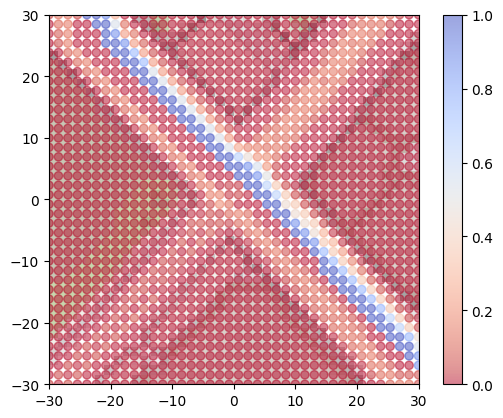

In [16]:
plot = support.scatter(bearing = 270, speed = 40, plot_basemap=True, alpha=0.5, cmap = "coolwarm_r")
plt.colorbar(plot)
pass

In [17]:
from matplotlib.animation import ArtistAnimation


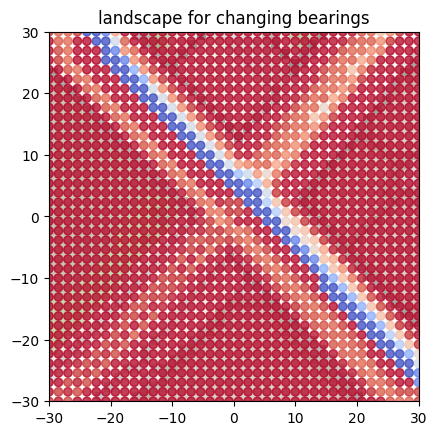

In [19]:
s=40
b=0
relation_name = "follows"
location_type = "tertiary"

frames = 36
ims = []
target = support #dsm.get(relation_name, location_type).parameters

fig, ax = plt.subplots()
plt.title( "landscape for changing bearings")#   f"{relation_name}(X, {location_type}), speed {s}") #
for i in range(frames):
    b = 360 / (frames) * i
    img = target.scatter(plot_basemap=True, bearing=b, speed=s, cmap="coolwarm_r", ax=ax, alpha=0.5, animated=True, method="slinear")
    
    if i == 0:
        target.scatter(plot_basemap=True, bearing=b, speed=s, cmap="coolwarm_r", ax=ax, alpha=0.5)
    
    ims.append([img])

ani = ArtistAnimation(fig, ims, interval = 300, blit = True, )
ani.save(filename="data/landscape_bearings.gif", writer="pillow")